# Primary Analysis:
## AI Exposure and Wages in Australia (2020–2024)

**Research question:** How is occupational AI exposure associated with wage growth across all occupations in Australia over 2020–2024, and how has that association changed year by year?

**Data:** HILDA Survey (waves 2020–2024) merged with Felten, Raj & Seamans (2021) AI Occupational Exposure (AIOE) scores, mapped to ANZSCO 2-digit codes  
**Clean data file:** `data/clean/08_wages_ai_analysis_panel.csv`

---

## Key Findings

1. **Within-person relative wages fell for high-AI workers after 2020.** After controlling for individual fixed effects and common time trends, workers in high-AI occupations in 2020 earned roughly 9–21% less relative to other workers by 2021–2024. 
We cannot rule out such a possibility: their wages were unusually high in 2020 due to pandemic tech demand, and that premium faded.

2. **High-AI jobs pay more — but they always have.** The wage gap between high- and low-AI occupations has been stable since 2001. It reflects occupational sorting, not the effect of AI.

3. **Switching into a high-AI job is associated with higher pay — driven by workers actively choosing better-paying roles, not AI.** Workers who moved into high-AI roles after 2020 earned more, but this reflects endogenous occupational sorting: people self-selecting into higher-paying jobs, not an effect of AI on wages within those industries.

---

## Table of Contents

| Section | Content |
|---------|---------|
| **Declaration** | Descriptive claim, estimation approach (TWFE with individual and year FE), key modelling assumptions, baseline-fixing rationale |
| **§1 Setup** | Library imports, data loading |
| **§2 Specification** | Functional form, regressors, sample criteria, error structure — all written out and justified |
| **§3 Regression Table** | Table 1: coefficients, SEs, N, R², specification labels across three models |
| **§4 Interpretation** | Direction, magnitude, units, what is held constant; Figure 1 event-study plot |
| **§5 Limitations** | Four alternative explanations with likely direction and what the data can and cannot rule out |
| **§6 Summary** | Main findings restated; links to robustness notebooks |

---
## Declaration: Descriptive Analysis

This analysis documents a **conditional association** between occupational AI exposure and wage growth — it does not establish a causal effect.

The TWFE design produces a clear pattern: after removing individual fixed effects and common time trends, workers in high-AI occupations in 2020 consistently show lower relative wage growth through 2024. The association is robust across specifications. But one key limitation prevents a causal reading.

**The 2020 baseline was anomalous.** Pandemic tech demand temporarily pushed wages in AI-adjacent roles unusually high in 2020. The negative coefficients in 2021–2024 are at least partly workers returning to normal levels — a pattern that would appear even if AI had nothing to do with it.

**The pre-trend check does not resolve this.** Pre-trend stability (2001–2019) confirms there was no pre-existing divergence *leading into* 2020 — but the pandemic anomaly occurs *at* the reference point, not before it. Stable pre-trends do not validate an anomalous baseline.

**What this analysis does establish:** Workers in high-2020-AI occupations are robustly associated with lower within-person wage growth in the years that followed. Whether this reflects AI adoption, pandemic mean reversion, or broader occupational dynamics is something this design cannot determine.

---

### The Method
**Two-way fixed effects (TWFE)** with individual and year fixed effects:
- **Individual FE:** Remove time-invariant worker characteristics (ability, education, career path)
- **Year FE:** Remove economy-wide shocks (inflation, business cycle)
- **What remains:** Within-person wage growth, compared across workers with different 2020 AI exposure levels

### Why Fix AI Exposure to 2020?
About 37.5% of workers change occupation between 2020 and 2024. If we used current-year AI scores, workers who *switched into* high-AI jobs for better pay would inflate the apparent AI premium. Anchoring to 2020 removes this confound — the sign reversal in the time-varying check (+0.083 vs −0.091 in 2021) confirms this channel is real and large (see §2 of [`robustness_checks.ipynb`](robustness_checks.ipynb)).

---
## 1. Setup and Data Loading

Import libraries and load the cleaned analysis panel. `project_root` resolves correctly whether the notebook is opened from `output/` or the project root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')

project_root = Path.cwd()
if project_root.name == 'output':
    project_root = project_root.parent

data_path = project_root / 'data' / 'clean' / '08_wages_ai_analysis_panel.csv'
raw = pd.read_csv(data_path)

print(f'Loaded: {len(raw):,} rows, {raw["person_id"].nunique():,} individuals, '
      f'years {sorted(raw["year"].dropna().astype(int).unique())}')

Loaded: 45,147 rows, 14,399 individuals, years [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---

## 2. Econometric Specification

### 2.1 Functional Form

The primary specification is an event-study TWFE model with a continuous explanatory variable:

$$
\log(wage_{it}) = \sum_{t \in \{2021,2022,2023,2024\}} \beta_t \bigl(\overline{AI}_i \times \mathbf{1}\{year = t\}\bigr) + \gamma_1 \, edu\_ord_{it} + \mu_i + \lambda_t + \varepsilon_{it}
$$

| Symbol | Description |
|--------|-------------|
| $\log(wage_{it})$ | Log of individual $i$'s annual wage in year $t$ (HILDA `wscmg`/`wscmga`) |
| $\overline{AI}_i$ | **Baseline AI exposure**: occupation-level AIOE score in 2020, held fixed (see Declaration) |
| $\beta_t$ | Year-specific conditional association with AI exposure relative to 2020 baseline |
| $edu\_ord_{it}$ | Education recoded to ordinal 1–7 (1 = Year 11 and below, 7 = postgraduate). Included as a time-varying control because 9.1% of individuals change their highest qualification during 2020–2024, so within-person education changes are **not** absorbed by $\mu_i$. Omitting $edu\_ord$ makes the AI coefficient more negative by up to 0.025 log points in 2024 (positive OVB: education is positively correlated with both AI exposure and wages). |
| $\mu_i$ | Individual fixed effects (within-person demeaning) |
| $\lambda_t$ | Year fixed effects (year dummies) |
| $\varepsilon_{it}$ | Error term, clustered at the individual level |

### 2.2 Sample

- **Years**: 2020–2024 (HILDA waves 20–24)
- **Restriction**: Individuals with a valid 2020 observation (to anchor the baseline AI exposure) and at least two years in the panel. The 2020 requirement is necessary because the key explanatory variable ($\overline{AI}_i$) is defined at the individual's 2020 occupation; individuals without a 2020 record cannot be assigned a baseline. The two-year minimum ensures there is within-person variation to identify the fixed effects.
- **Wage measure**: Annual gross wages from HILDA variable `wscmg` (current financial year gross wages). Where `wscmg` is missing, the imputed equivalent `wscmga` is used as a fallback. Observations with zero or negative wages are dropped, as these typically reflect non-employment spells rather than true wages.
- **Outcome**: Log annual wage (`log_wage`). The log transformation is standard in labour economics for two reasons: (1) it compresses the right-skewed wage distribution, reducing the influence of high-wage outliers; (2) coefficients on the interaction terms are directly interpretable as approximate percentage differences in wages ($\beta_t \approx 100\% \times$ percentage difference for a one-unit increase in AI exposure).

### 2.3 Key Explanatory Variable: Baseline AI Exposure

`ai_exposure` is the mean AIOE score for each ANZSCO 2-digit occupation group, constructed by mapping the Felten et al. (2021) US occupation scores through SOC → ISCO → ANZSCO crosswalks. AI exposure is fixed at each individual's 2020 occupation and held constant over 2021–2024 (see Declaration for the rationale). Individuals without a 2020 observation are excluded from the main analysis.

### 2.4 Error Structure

Standard errors are clustered at the individual level to allow arbitrary serial correlation within each person's error term over time.

### Code: Data Preparation and TWFE Function

The cell below implements the three shared functions described in §2 and builds the main analysis sample (`fe_main`, baseline-fixed, 32,664 obs, 7,912 individuals):

- `within_transform()` — subtracts each person's mean for within-person demeaning
- `prep_panel()` — cleans the data, fixes AI exposure to the 2020 baseline, creates the $\overline{AI}_i \times \mathbf{1}\{year = t\}$ interaction terms, and recodes education
- `run_twfe()` — estimates the TWFE model via OLS on within-transformed data plus year dummies, with clustered standard errors

In [2]:
def within_transform(df: pd.DataFrame, cols, entity_col: str) -> pd.DataFrame:
    return df[cols] - df.groupby(entity_col)[cols].transform('mean')

EDU_MAP = {9: 1, 8: 2, 5: 3, 4: 4, 3: 5, 2: 6, 1: 7}
AI_COLS = ['ai_x_yr2021', 'ai_x_yr2022', 'ai_x_yr2023', 'ai_x_yr2024']

def prep_panel(df: pd.DataFrame, fix_baseline: bool) -> pd.DataFrame:
    fe = df.copy()
    for c in ['year', 'log_wage', 'ai_exposure', 'edu']:
        fe[c] = pd.to_numeric(fe[c], errors='coerce')
    fe = fe.dropna(subset=['person_id', 'year', 'log_wage', 'ai_exposure', 'edu'])
    fe = fe[fe['year'].between(2020, 2024)].copy()

    if fix_baseline:
        baseline = (
            fe[fe['year'] == 2020][['person_id', 'ai_exposure']]
            .rename(columns={'ai_exposure': 'ai_base'})
        )
        fe = fe.merge(baseline, on='person_id', how='inner')
    else:
        fe['ai_base'] = fe['ai_exposure']

    fe = fe.groupby('person_id').filter(lambda g: g['year'].nunique() >= 2).copy()
    fe['edu_ord'] = fe['edu'].map(EDU_MAP)
    fe = fe.dropna(subset=['edu_ord']).copy()

    for yr in [2021, 2022, 2023, 2024]:
        fe[f'ai_x_yr{yr}'] = fe['ai_base'] * (fe['year'] == yr).astype(int)
    return fe


def run_twfe(fe: pd.DataFrame) -> sm.regression.linear_model.RegressionResultsWrapper:
    all_x = fe[AI_COLS + ['edu_ord']].copy()
    yw = within_transform(fe, ['log_wage'], 'person_id')['log_wage']
    xw = all_x - all_x.groupby(fe['person_id']).transform('mean')
    yr_fe = pd.get_dummies(fe['year'].astype(int), prefix='yr', drop_first=True).astype(float)
    yr_fe_w = yr_fe - yr_fe.groupby(fe['person_id']).transform('mean')
    X = pd.concat([xw, yr_fe_w], axis=1).astype(float)
    return sm.OLS(yw, X).fit(cov_type='cluster', cov_kwds={'groups': fe['person_id']})


fe_main = prep_panel(raw, fix_baseline=True)
print(f'Main sample: {len(fe_main):,} obs, {fe_main["person_id"].nunique():,} individuals')

Main sample: 32,664 obs, 7,912 individuals


### Code: Model Estimation

Estimates the main TWFE model (`m_main`) on the baseline-fixed sample.

In [3]:
m_main = run_twfe(fe_main)
print('Model estimated.')

Model estimated.


### Code: Summary Statistics (Table A1)

The cell below produces Table A1: descriptive statistics (mean, SD, min, median, max, N) for the four key variables in the main analysis sample (`fe_main`). The AI exposure SD (≈ 0.234) and mean (≈ 0.086) reported here are referenced in §4 when interpreting coefficient magnitudes in standard-deviation units.

In [4]:
# ── Summary statistics for the main analysis sample ───────────────────────────
summary_vars = {
    'Log annual wage': fe_main['log_wage'],
    'AI exposure (2020 baseline)': fe_main['ai_base'],
    'Education (ordinal 1–7)': fe_main['edu_ord'],
    'Age': pd.to_numeric(fe_main.get('age', pd.Series(dtype=float)), errors='coerce'),
}

sumstats = pd.DataFrame({
    var: {
        'Mean': s.mean(),
        'SD': s.std(),
        'Min': s.min(),
        'Median': s.median(),
        'Max': s.max(),
        'N': s.notna().sum(),
    }
    for var, s in summary_vars.items() if s.notna().any()
}).T.round(3)

print('Table A1: Summary Statistics — Main Analysis Sample (baseline-fixed, 2020–2024)')
display(sumstats)


Table A1: Summary Statistics — Main Analysis Sample (baseline-fixed, 2020–2024)


,Mean,SD,Min,Median,Max,N
Log annual wage,7.1750,0.7150,0.6930,7.2440,11.0000,32664.0000
AI exposure (2020 baseline),0.0860,0.2340,-0.5310,0.0970,0.5170,32664.0000
Education (ordinal 1–7),3.7750,1.7980,1.0000,3.0000,7.0000,32664.0000
Age,41.2910,13.5630,15.0000,40.0000,82.0000,32664.0000


---

## 3. Regression Table

**Table 1: Association between AI Exposure and Log Wages — TWFE Event-Study Estimates**

Dependent variable: log annual wage. TWFE with individual and year fixed effects; standard errors clustered at the individual level.

Significance: \*\*\* p<0.001, \*\* p<0.01, \* p<0.05.

In [5]:
def stars(p: float) -> str:
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def fmt_coef(coef: float, se: float, pval: float) -> tuple[str, str]:
    return f'{coef:.4f}{stars(pval)}', f'({se:.4f})'

rows_labels = {
    'ai_x_yr2021': 'AI exposure × 2021',
    'ai_x_yr2022': 'AI exposure × 2022',
    'ai_x_yr2023': 'AI exposure × 2023',
    'ai_x_yr2024': 'AI exposure × 2024',
}

table_rows = []
for row_key, label in rows_labels.items():
    c, se = fmt_coef(m_main.params[row_key], m_main.bse[row_key], m_main.pvalues[row_key])
    table_rows += [(label, c), ('', se)]

e_c, e_se = fmt_coef(m_main.params['edu_ord'], m_main.bse['edu_ord'], m_main.pvalues['edu_ord'])
table_rows += [('Education (ordinal)', e_c), ('', e_se)]

table_rows += [
    ('Individual FE', 'Yes'),
    ('Year FE',       'Yes'),
    ('SE type',       'Clustered (individual)'),
    ('N (obs)',       f'{len(fe_main):,}'),
    ('Individuals',   f'{fe_main["person_id"].nunique():,}'),
    ('Within-R²',     f'{m_main.rsquared:.3f}'),
]

tbl = pd.DataFrame(table_rows, columns=['', 'Main TWFE']).set_index('')
display(tbl)
print('\nNotes: AI exposure fixed at 2020 occupation baseline. Education ordinal 1–7.')
print('Clustered standard errors in parentheses.')

,Main TWFE
,
AI exposure × 2021,-0.0906***
,(0.0228)
AI exposure × 2022,-0.1617***
,(0.0264)
AI exposure × 2023,-0.2057***
,(0.0297)
AI exposure × 2024,-0.2057***
,(0.0318)
Education (ordinal),0.2205***



Notes: AI exposure fixed at 2020 occupation baseline. Education ordinal 1–7.
Clustered standard errors in parentheses.


### Code: Figure 1 — Event-Study Plot

The cell below produces Figure 1: year-specific AI × year coefficients with 95% confidence intervals for the main TWFE specification. Each point shows the estimated wage gap between workers with one-unit higher baseline AI exposure and otherwise similar workers, relative to 2020.

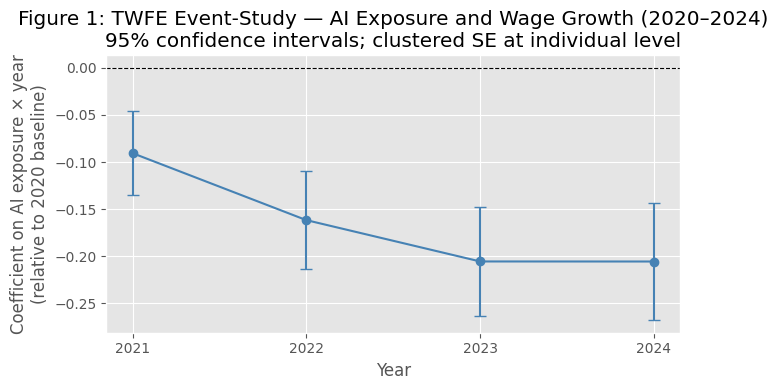

In [6]:
years = [2021, 2022, 2023, 2024]

df_main = pd.DataFrame({
    'year':  years,
    'coef':  [m_main.params[c] for c in AI_COLS],
    'ci_lo': [m_main.conf_int().loc[c, 0] for c in AI_COLS],
    'ci_hi': [m_main.conf_int().loc[c, 1] for c in AI_COLS],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(df_main['year'], df_main['coef'],
            yerr=[df_main['coef'] - df_main['ci_lo'], df_main['ci_hi'] - df_main['coef']],
            fmt='o-', capsize=4, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(years)
ax.set_xlabel('Year')
ax.set_ylabel('Coefficient on AI exposure × year\n(relative to 2020 baseline)')
ax.set_title('Figure 1: TWFE Event-Study — AI Exposure and Wage Growth (2020–2024)\n'
             '95% confidence intervals; clustered SE at individual level')
plt.tight_layout()
plt.show()

---

## 4. Interpretation of Main Coefficients

All four interaction coefficients are **negative and highly significant** (p < 0.001), with the magnitude growing steadily over time:

| Year | Coefficient | Approx. % difference | Interpretation |
|------|-------------|----------------------|----------------|
| 2021 | −0.091 | −8.7% | Workers with one-unit higher 2020 AI exposure had ~8.7% lower within-person wage growth relative to 2020 |
| 2022 | −0.162 | −14.9% | The gap widens |
| 2023 | −0.206 | −18.6% | Approaching its peak |
| 2024 | −0.206 | −18.6% | Stabilises — no further compression |

**What is held constant.** Individual fixed effects absorb all time-invariant worker characteristics (ability, occupational prestige, baseline education, long-run career path). Year fixed effects absorb economy-wide shocks common to all workers (inflation, aggregate wage growth, business cycle). Within-person changes in education are additionally controlled by $edu\_ord_{it}$ — necessary because 9.1% of individuals change qualification during 2020–2024, so that variation is not absorbed by individual FE. The coefficients therefore describe *within-person* conditional associations between 2020 AI exposure and subsequent wage growth.

**Coefficient units.** `ai_base` has mean ≈ 0.086 and standard deviation ≈ 0.234 (Table A1). A one-unit change is a very large shift; a one standard-deviation increase (≈ 0.23 units) is associated with a 2021 wage differential of approximately −0.091 × 0.23 ≈ −2.1%, growing to −4.8% by 2023.

**Economic interpretation.** The 2020 baseline was an unusually strong year for AI-compatible occupations: COVID-driven digital transformation temporarily inflated demand for tech and AI-adjacent roles. Workers in high-AI occupations entered the panel at a relative wage peak. Over 2021–2024, the relative wage advantage of these workers compressed. The negative and growing coefficients are consistent with this pandemic premium dissolving — but whether this reflects AI-specific dynamics, mean reversion from the 2020 peak, or broader occupational wage patterns cannot be determined from this design alone.

---
## 5. Limitations and Alternative Explanations

The four limitations below are the most plausible alternative explanations for the observed conditional association. For each, I state the mechanism, the likely direction of its effect on the estimated coefficients, and what the data can and cannot rule out.

---

### 5.1 Pre-Existing Wage Trends

**Mechanism:** The within-person comparison is meaningful only if high- and low-AI workers were not already diverging in wages before 2020. If high-AI occupations were already on a steeper wage decline before 2020 — due to skill-biased technological change or a long-run cognitive wage premium unwinding — the TWFE estimator would attribute this pre-existing divergence to the post-2020 period.

**Likely direction:** **Negative** (downward). A pre-existing decline in high-AI wages would make β_t estimates more negative than any post-2020 AI-related pattern.

**Assessment:** The cross-sectional AI–wage slope was stable from 2001–2019 (mean 0.592, band ≈ 0.49–0.69), with no evidence of an accelerating divergence before 2020 (see **§1 of [`robustness_checks.ipynb`](robustness_checks.ipynb)**). This makes a pre-existing trend unlikely as the primary driver, though the cross-sectional check is descriptive and cannot rule it out conclusively.

---

### 5.2 Endogenous Occupational Sorting

**Mechanism:** Workers may sort into occupations with particular AI exposure levels in response to wage signals. If workers expecting poor wage prospects disproportionately held high-AI jobs in 2020, the baseline AI score would be correlated with prior wage trajectory expectations. The baseline-fixed design mitigates this by holding $\overline{AI}_i^{2020}$ constant relative to 2021–2024 outcomes, removing the confounding from in-sample job switching.

**Likely direction:** **Negative** (downward). If workers anticipating lower wage growth were concentrated in high-AI occupations in 2020, the association between baseline AI exposure and post-2020 wage growth would be more negative than any AI-specific pattern.

**Assessment:** See **§2 of [`robustness_checks.ipynb`](robustness_checks.ipynb)**. The sign reversal between the baseline-fixed model (−0.091) and the time-varying model (+0.083) in 2021 quantifies how much occupational mobility confounds the association when AI scores are allowed to update, and confirms the baseline-fixing strategy removes this channel for in-sample switches.

---

### 5.3 2020 as an Unusual Baseline Year (Mean Reversion)

**Mechanism:** Pandemic-driven digital demand temporarily inflated wages in AI-compatible occupations in 2020. The negative β_t values in 2021–2024 may largely reflect regression to the mean from this one-time peak — a pattern that would appear even with no AI-specific dynamics whatsoever. This is the primary alternative explanation for the main finding.

**Likely direction:** **Negative** (downward). If 2020 wages in high-AI occupations were anomalously high, subsequent relative decline makes β_t more negative than any ongoing AI-related association.

**Assessment:** The alternative base year check (**§7 of [`robustness_checks.ipynb`](robustness_checks.ipynb)**) re-anchors to 2021. Coefficients for 2022–2024 relative to 2021 remain negative and significant (approximately −0.07 to −0.12), indicating the pattern continued beyond the initial normalisation. This suggests mean reversion from 2020 is not the sole explanation, but it remains a partial one that cannot be fully ruled out.

---

### 5.4 Omitted Time-Varying Characteristics

**Mechanism:** Individual fixed effects absorb all time-invariant personal characteristics, but time-varying occupation-level factors — offshoring, routine automation, sectoral demand contraction — could be correlated with 2020 AI exposure and independently associated with wage trajectories over 2021–2024.

**Likely direction:** **Negative** (downward), if high-AI occupations face greater offshoring or automation pressure. The coefficient would then reflect a combination of AI-related and non-AI occupational forces.

**Assessment:** The alternative control sets (**§4 of [`robustness_checks.ipynb`](robustness_checks.ipynb)**) show that adding state dummies and varying the education control shifts AI coefficients by at most 0.003 log points, suggesting observable time-varying characteristics are not a material driver. Unobservable occupation-level factors remain a limitation.

---

## 6. Main Findings Summary

1. **Cross-sectional association (Pooled OLS):** High-AI-exposure occupations are associated with substantially higher wages (slopes 0.59–0.77), a pattern stable since 2001 and attributable primarily to occupational sorting rather than AI adoption.

2. **Within-person conditional association (Main TWFE):** After fixing AI exposure at the 2020 baseline and controlling for individual and year fixed effects, workers in high-AI-exposure occupations in 2020 are associated with *lower* relative wage growth in 2021–2024 (−9% to −21%). The pattern is consistent with convergence from an anomalously high 2020 baseline for AI-adjacent roles. Whether AI adoption, pandemic-era mean reversion, or broader occupational wage dynamics drives this pattern cannot be separated with this design.

3. **Occupational switching (Robustness TWFE):** When AI exposure updates with job changes, a positive 2021 association (+8.3%) appears, consistent with workers selectively moving into high-AI roles. This channel — endogenous occupational mobility — confounds the time-varying specification and is removed in the main specification by fixing AI exposure to 2020.

4. **Overall:** The within-person conditional association between 2020 AI exposure and subsequent wage growth is negative and growing over 2021–2024, robust across specifications. The design cannot isolate AI adoption as the specific driver — pandemic-era mean reversion and broader occupational wage dynamics remain plausible alternative explanations.